In [1]:
import pandas as pd
import numpy as np

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
import tensorflow.keras.backend as K

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

from pathlib import Path
import math
import os

In [2]:
#os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

# Datos (15 min data)

[Data](https://archive.ics.uci.edu/dataset/321/electricityloaddiagrams20112014)

In [3]:
df_15min = pd.read_csv('../data/electricityloaddiagrams20112014/LD2011_2014.txt', sep=';', parse_dates=[0], index_col=0, decimal=',', dtype=np.float64)
df_15min.head()

,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
2011-01-01 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 00:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 00:45:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 01:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
df_15min.describe()

,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
count,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,...,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000
mean,3.970785,20.768480,2.918308,82.184490,37.240309,141.227385,4.521338,191.401476,39.975354,42.205152,...,218.213701,37607.987537,1887.427366,2940.031734,65.413150,9.269709,424.262904,94.704717,625.251734,8722.355145
std,5.983965,13.272415,11.014456,58.248392,26.461327,98.439984,6.485684,121.981187,29.814595,33.401251,...,204.833532,38691.954832,1801.486488,2732.251967,65.007818,10.016782,274.337122,80.297301,380.656042,9195.155777
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.844950,0.000000,36.585366,15.853659,71.428571,0.565291,111.111111,13.986014,9.677419,...,5.710207,0.000000,0.000000,0.000000,13.037810,0.000000,0.000000,30.050083,83.944282,0.000000
50%,1.269036,24.893314,1.737619,87.398374,39.024390,157.738095,2.826456,222.222222,40.209790,40.860215,...,131.334761,24100.000000,1050.632911,2136.363636,31.290743,7.021650,525.899912,76.794658,758.064516,0.000000
75%,2.538071,29.871977,1.737619,115.853659,54.878049,205.357143,4.522329,279.461279,57.692308,61.290323,...,403.283369,54800.000000,3312.236287,5363.636364,108.213820,11.702750,627.743635,151.919866,875.366569,17783.783784
max,48.223350,115.220484,151.172893,321.138211,150.000000,535.714286,44.657999,552.188552,157.342657,198.924731,...,852.962170,192800.000000,7751.054852,12386.363636,335.071708,60.269163,1138.718174,362.270451,1549.120235,30918.918919


In [5]:
df_15min.shape

(140256, 370)

# Preprocesado

In [6]:
df_15min = df_15min.sort_index()
df_15min = df_15min[~df_15min.index.duplicated(keep="first")]

In [7]:
expected_freq = pd.infer_freq(df_15min.index[:8]) or "15T"
print("Inferred 15-min frequency (approx):", expected_freq)

Inferred 15-min frequency (approx): 15min


In [8]:
full_idx = pd.date_range(df_15min.index.min(), df_15min.index.max(), freq="15T")
if len(full_idx) != len(df_15min.index):
    print("Reindexing to full 15-min grid and forward-filling missing values...")
    df_15min = df_15min.reindex(full_idx).ffill()

/tmp/ipykernel_605506/507045246.py:1: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  full_idx = pd.date_range(df_15min.index.min(), df_15min.index.max(), freq="15T")


In [9]:
df_daily = df_15min.resample("1D").sum()

print("Daily shape:", df_daily.shape)
df_daily.head(3)

Daily shape: (1462, 370)


,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
2011-01-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
df_daily

,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
2011-01-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
2011-01-02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
2011-01-03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
2011-01-04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
2011-01-05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014-12-28,227.157360,2131.578947,151.172893,14327.235772,6776.829268,20122.023810,429.621255,25255.892256,5118.881119,4794.623656,...,28815.132049,3272100.0,220721.518987,257477.272727,8169.491525,552.369807,45914.837577,4405.676127,66135.630499,1.553189e+06
2014-12-29,248.730964,2212.660028,160.729800,14067.073171,7198.780488,22824.404762,550.593556,30286.195286,6697.552448,6337.634409,...,28825.124911,3109100.0,206852.320675,269090.909091,8438.070404,1153.891164,53928.884987,12914.858097,73882.697947,1.806486e+06
2014-12-30,232.233503,2205.547653,165.073849,14290.650407,7189.024390,23880.952381,586.772188,30909.090909,6487.762238,6489.247312,...,28488.222698,2904300.0,204126.582278,263613.636364,10615.384615,892.334699,56334.503951,15996.661102,73950.146628,1.867568e+06
2014-12-31,229.695431,2273.115220,166.811468,14006.097561,7023.170732,23511.904762,690.785755,28700.336700,6211.538462,5034.408602,...,26970.735189,2748800.0,162556.962025,215886.363636,7415.906128,530.134582,50259.877085,13245.409015,70416.422287,1.365892e+06


In [11]:
W = 30   # lookback window
H = 7    # forecast horizon

def make_windows(arr, window=W, horizon=H):
    X, y = [], []
    for i in range(len(arr) - window - horizon + 1):
        X.append(arr[i:i+window])
        y.append(arr[i+window:i+window+horizon].ravel())
    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)
    return X, y


In [12]:
X = np.empty(shape=(0,W))
y = np.empty(shape=(0,H))

n_cols = len(df_daily.columns)

for i in range(n_cols):
    arr = df_daily.iloc[:,i].values
    X_, y_ = make_windows(arr, W, H)
    X = np.concatenate([X, X_], axis=0)
    y = np.concatenate([y, y_], axis=0)

In [13]:
X.shape

(527620, 30)

In [14]:
y.shape

(527620, 7)

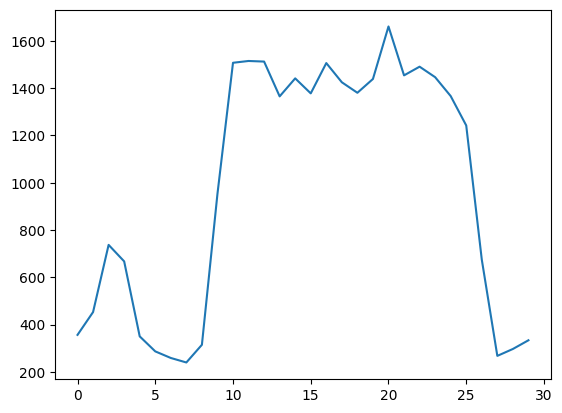

In [15]:
series = X[400]
plt.plot(series)
plt.show()

In [16]:
permutation = np.random.permutation(len(X))

X = X[permutation]
y = y[permutation]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25)

In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [19]:
X_train_scaled.shape

(316572, 30)

In [20]:
scaler2 = StandardScaler()
y_train_scaled = scaler2.fit_transform(y_train)
y_val_scaled = scaler2.transform(y_val)
y_test_scaled = scaler2.transform(y_test)

# Modelo 

## Para una celda LSTM

**Forget gate**

$
F_t = \sigma(W_f x_t + U_f H_{t-1} + b_f)
$

**Input gate**

$
I_t = \sigma(W_i x_t + U_i H_{t-1} + b_i)
$

**Candidate cell state**

$
\tilde{C}_t = \tanh(W_c x_t + U_c H_{t-1} + b_c)
$

**New cell state**

$
C_t = f_t \odot C_{t-1} + I_t \odot \tilde{C}_t
$

**Output gate**

$
O_t = \sigma(W_o x_t + U_o H_{t-1} + b_o)
$

**New hidden state**

$
H_t = O_t \odot \tanh(C_t)
$

Entonces la función de transición nos queda:

$
f_{\theta}(x_t, H_{t-1}, C_{t-1}) = (h_t, c_t)
$



![image](https://d2l.ai/_images/lstm-3.svg)

[Referencia](https://d2l.ai/chapter_recurrent-modern/lstm.html)

In [21]:
class Seq2Seq:
    def __init__(self, window=W, horizon=H, kernel_init="glorot_uniform", recurrent_init="orthogonal"):
        self.window=window
        self.horizon=horizon
        self.optimizer = optimizers.SGD(learning_rate=0.1)
        self.loss_fn = tf.keras.losses.MeanSquaredError()
        self.kernel_init = kernel_init
        self.recurrent_init = recurrent_init
        self.model = self.build_model()
    
    def build_model(self):
        inputs = tf.keras.Input(shape=(self.window, 1))
        x = layers.LSTM(128, return_sequences=True, kernel_initializer=self.kernel_init, recurrent_initializer=self.recurrent_init, bias_initializer=tf.keras.initializers.Constant(0.0))(inputs)
        x = layers.LSTM(64, kernel_initializer=self.kernel_init,recurrent_initializer=self.recurrent_init, bias_initializer=tf.keras.initializers.Constant(0.0))(x)
        outputs = layers.Dense(self.horizon)(x)
        model = tf.keras.Model(inputs, outputs)
        return model

    def train_step(self, x, y):
        with tf.GradientTape() as tape:
            y_pred = self.model(x)
            loss = self.loss_fn(y, y_pred)
        grads = tape.gradient(loss, self.model.trainable_variables)
        grad_norm = tf.reduce_mean([tf.norm(g) for g in grads if g is not None])
        #grad_norm = tf.linalg.global_norm(grads)
        self.optimizer.apply_gradients(zip(grads, self.model.trainable_variables))
        return loss, grad_norm


In [22]:
EPOCHS = 100
BATCH_SIZE = 128

def batch_sampler(X, y, batch_size):
    n = X.shape[0]
    idx = tf.random.shuffle(tf.range(n))

    for i in range(0, n, batch_size):
        batch_idx = idx[i:i + batch_size]
        yield tf.gather(X, batch_idx), tf.gather(y, batch_idx)


def train_model(kernel_init, recurrent_init):
    loss_hist = []
    grad_hist = []

    model = Seq2Seq(kernel_init=kernel_init,recurrent_init=recurrent_init)

    for epoch in range(EPOCHS):
        batch_losses, grad_losses = [], []
        for x_batch, y_batch in batch_sampler(X_train_scaled, y_train_scaled, BATCH_SIZE): 
            loss, grad = model.train_step(x_batch, y_batch)
            batch_losses.append(loss.numpy())
            grad_losses.append(grad.numpy())
        loss_hist.append(np.mean(batch_losses))
        grad_hist.append(np.mean(grad_losses))
        print(epoch,"loss:", np.mean(batch_losses), "grad:", np.mean(grad_losses))
    return loss_hist, grad_hist

In [23]:
configs = {
    "glorot_uniform": ("glorot_uniform", "orthogonal"),
    "he_normal": ("he_normal", "he_normal"),
    "orthogonal": ("orthogonal", "orthogonal"),
    "random_normal": (
        tf.keras.initializers.RandomNormal(stddev=0.2),
        tf.keras.initializers.RandomNormal(stddev=0.2)
    )
}

results = {}

for name, (kernel_init, recurrent_init) in configs.items():
    print(f"\nEntrenando modelo: {name}")
    results[name] = train_model(kernel_init, recurrent_init)


Entrenando modelo: glorot_uniform


I0000 00:00:1766537368.183701  605506 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13698 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Ti SUPER, pci bus id: 0000:07:00.0, compute capability: 8.9
I0000 00:00:1766537369.269566  605827 cuda_dnn.cc:529] Loaded cuDNN version 91001


0 loss: 0.12661442 grad: 0.1607902
1 loss: 0.025117239 grad: 0.08686402
2 loss: 0.019068094 grad: 0.06316747
3 loss: 0.017748564 grad: 0.05524327
4 loss: 0.016758291 grad: 0.054224007
5 loss: 0.017143764 grad: 0.05367102
6 loss: 0.016112892 grad: 0.049326137
7 loss: 0.015665013 grad: 0.047674876
8 loss: 0.015712023 grad: 0.045862306
9 loss: 0.015569604 grad: 0.044386372
10 loss: 0.01592829 grad: 0.045083098
11 loss: 0.016329022 grad: 0.042396054
12 loss: 0.015559842 grad: 0.042412266
13 loss: 0.01517094 grad: 0.0418859
14 loss: 0.015492163 grad: 0.042015247
15 loss: 0.015139215 grad: 0.040489636
16 loss: 0.015234048 grad: 0.040924195
17 loss: 0.014698602 grad: 0.039246578
18 loss: 0.014773156 grad: 0.039074834
19 loss: 0.014501586 grad: 0.038691714
20 loss: 0.014811138 grad: 0.03767149
21 loss: 0.014338057 grad: 0.037175827
22 loss: 0.015060627 grad: 0.039038908
23 loss: 0.01454919 grad: 0.037076738
24 loss: 0.014548193 grad: 0.038586855
25 loss: 0.014572452 grad: 0.040432565
26 loss: 

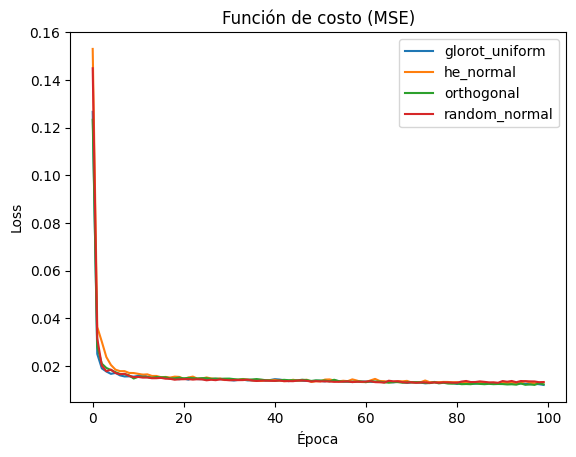

In [24]:
plt.figure()
for name, (loss_h, _) in results.items():
    plt.plot(loss_h, label=name)
plt.title("Función de costo (MSE)")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.show()


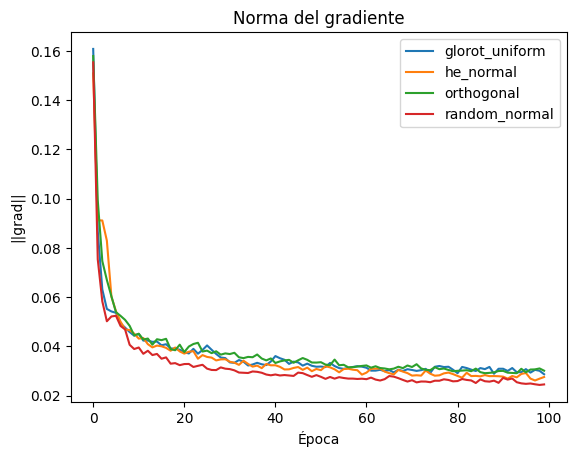

In [25]:
plt.figure()
for name, (_, grad_h) in results.items():
    plt.plot(grad_h, label=name)
plt.title("Norma del gradiente")
plt.xlabel("Época")
plt.ylabel("||grad||")
plt.legend()
plt.show()